In [1]:
import copy
import random
from collections import Counter

import matplotlib.pyplot as plt


import torch
import torch.nn.functional as F

from transformers import AutoTokenizer

from laya.sft import sft_step, evaluate
from laya.pretrained import PretrainedDecisionModel
from laya.dataset import (
    encode_decision_batch,
    raw_examples,
    LABELS,
    build_decision_examples,
    move_batch_to_device,
)

/Users/van/Documents/Van/Code/laya-from-scratch/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
torch.manual_seed(42)
random.seed(42)

# device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device = "cpu"

In [3]:
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [4]:
examples = build_decision_examples(raw_examples, LABELS, seed=42)

In [5]:
# train valid split

rng = random.Random(123)

indices = list(range(len(examples)))
rng.shuffle(indices)

cut = 48
train_indices = indices[:cut]
validate_indices = indices[cut:]

train_examples = [examples[e] for e in train_indices]
validate_examples = [examples[e] for e in validate_indices]

train_batch = encode_decision_batch(train_examples, tokenizer)
validate_batch = encode_decision_batch(validate_examples, tokenizer)

train_targets = torch.tensor(
    [e["target"] for e in train_examples], dtype=torch.long
).to(device)
validate_targets = torch.tensor(
    [e["target"] for e in validate_examples], dtype=torch.long
).to(device)

train_batch = move_batch_to_device(train_batch, device)
validate_batch = move_batch_to_device(validate_batch, device)

In [6]:
torch.manual_seed(42)

base_model = PretrainedDecisionModel(
    model_name=model_name,
    decision_hidden_dim=128,
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 60212.56it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### freeze pretrain


In [7]:
frozen_model = copy.deepcopy(base_model).to(device)

In [8]:
for para in frozen_model.backbone.parameters():
    para.requires_grad = False

In [9]:
sum(p.numel() for p in frozen_model.parameters() if p.requires_grad)

98561

In [10]:
# before train
(
    frozen_val_loss_before,
    frozen_val_accuracy_before,
    frozen_proba_before,
) = evaluate(
    model=frozen_model,
    input_ids=validate_batch["input_ids"],
    attention_mask=validate_batch["attention_mask"],
    option_marker_mask=validate_batch["option_marker_mask"],
    targets=validate_targets,
)
print(
    frozen_val_loss_before,
    frozen_val_accuracy_before,
)

1.384655475616455 0.3333333432674408


In [11]:
frozen_optimizer = torch.optim.AdamW(frozen_model.decision_head.parameters(), lr=1e-3)

frozen_train_loss = []
frozen_val_loss = []
frozen_val_accuracy = []
frozen_eval_steps = []

n_steps = 300
eval_every = 10

for step in range(n_steps):
    loss = sft_step(
        frozen_model,
        frozen_optimizer,
        train_batch["input_ids"],
        train_batch["attention_mask"],
        train_batch["option_marker_mask"],
        train_targets,
    )
    frozen_train_loss.append(loss)

    if step % eval_every == 0:
        val_loss, val_accuracy, _ = evaluate(
            frozen_model,
            validate_batch["input_ids"],
            validate_batch["attention_mask"],
            validate_batch["option_marker_mask"],
            validate_targets,
        )
        frozen_val_loss.append(val_loss)
        frozen_val_accuracy.append(val_accuracy)
        frozen_eval_steps.append(step)

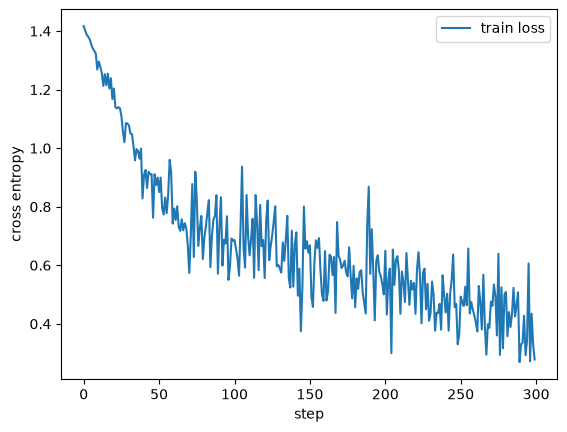

In [12]:
plt.figure()

plt.plot(
    frozen_train_loss,
    label="train loss",
)

plt.xlabel("step")
plt.ylabel("cross entropy")
plt.legend()

plt.show()

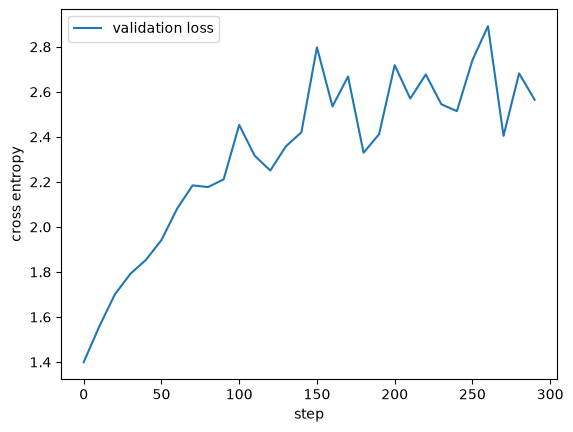

In [13]:
plt.figure()

plt.plot(
    frozen_eval_steps,
    frozen_val_loss,
    label="validation loss",
)

plt.xlabel("step")
plt.ylabel("cross entropy")
plt.legend()

plt.show()

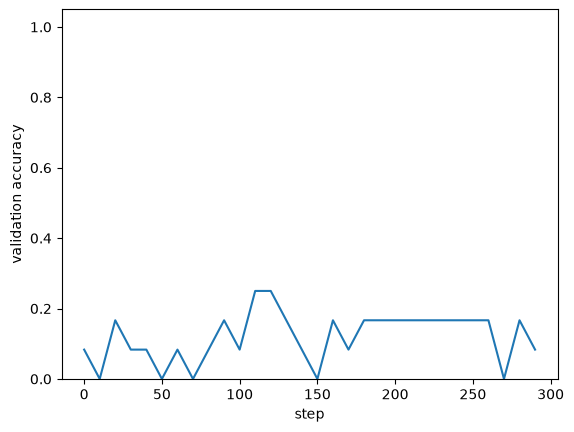

In [14]:
plt.figure()

plt.plot(
    frozen_eval_steps,
    frozen_val_accuracy,
)

plt.xlabel("step")
plt.ylabel("validation accuracy")
plt.ylim(0, 1.05)

plt.show()

In [15]:
(
    frozen_final_loss,
    frozen_final_accuracy,
    frozen_final_probabilities,
) = evaluate(
    model=frozen_model,
    input_ids=validate_batch["input_ids"],
    attention_mask=validate_batch["attention_mask"],
    option_marker_mask=validate_batch["option_marker_mask"],
    targets=validate_targets,
)
print("Frozen backbone:")

print(
    "Validation loss:",
    frozen_final_loss,
)

print(
    "Validation accuracy:",
    frozen_final_accuracy,
)

Frozen backbone:
Validation loss: 2.542149305343628
Validation accuracy: 0.1666666716337204


### fine tune all param


In [16]:
full_model = copy.deepcopy(base_model).to(device)

In [17]:
for para in full_model.backbone.parameters():
    para.requires_grad = True

In [18]:
# before train
(
    frozen_val_loss_before,
    frozen_val_accuracy_before,
    frozen_proba_before,
) = evaluate(
    model=full_model,
    input_ids=validate_batch["input_ids"],
    attention_mask=validate_batch["attention_mask"],
    option_marker_mask=validate_batch["option_marker_mask"],
    targets=validate_targets,
)
print(
    frozen_val_loss_before,
    frozen_val_accuracy_before,
)

1.384655475616455 0.3333333432674408


In [19]:
full_optimizer = torch.optim.AdamW(full_model.parameters(), lr=2e-5)

full_train_loss = []
full_val_loss = []
full_val_accuracy = []
full_eval_steps = []

n_steps = 300
eval_every = 10

for step in range(n_steps):
    loss = sft_step(
        full_model,
        full_optimizer,
        train_batch["input_ids"],
        train_batch["attention_mask"],
        train_batch["option_marker_mask"],
        train_targets,
    )
    full_train_loss.append(loss)

    if step % eval_every == 0:
        val_loss, val_accuracy, _ = evaluate(
            full_model,
            validate_batch["input_ids"],
            validate_batch["attention_mask"],
            validate_batch["option_marker_mask"],
            validate_targets,
        )

        full_val_loss.append(val_loss)
        full_val_accuracy.append(val_accuracy)
        full_eval_steps.append(step)

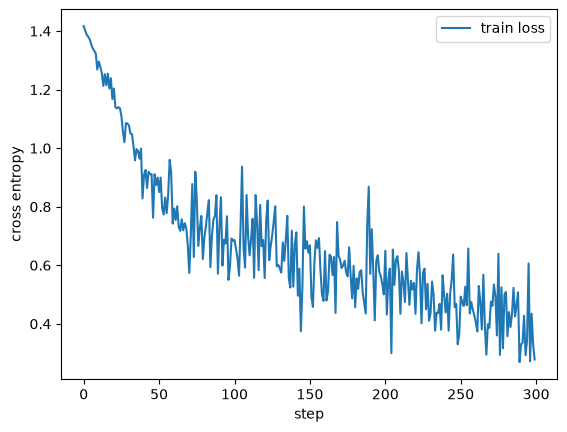

In [20]:
plt.figure()

plt.plot(
    frozen_train_loss,
    label="train loss",
)

plt.xlabel("step")
plt.ylabel("cross entropy")
plt.legend()

plt.show()

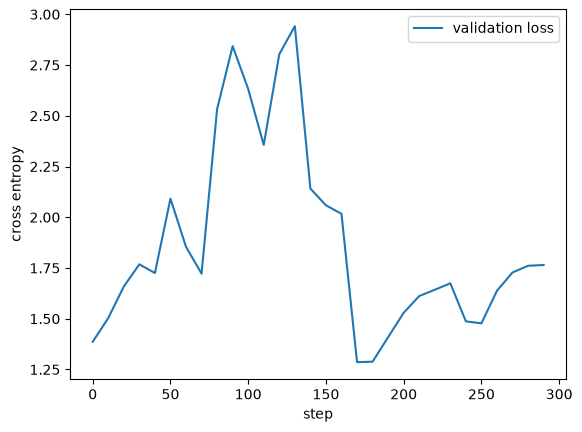

In [21]:
plt.figure()

plt.plot(
    full_eval_steps,
    full_val_loss,
    label="validation loss",
)

plt.xlabel("step")
plt.ylabel("cross entropy")
plt.legend()

plt.show()

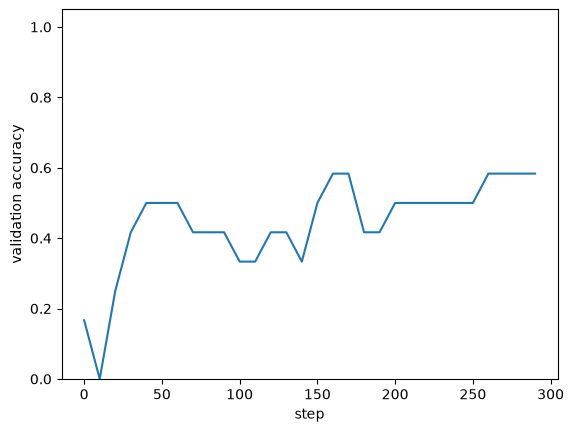

In [22]:
plt.figure()

plt.plot(
    full_eval_steps,
    full_val_accuracy,
)

plt.xlabel("step")
plt.ylabel("validation accuracy")
plt.ylim(0, 1.05)

plt.show()

In [23]:
(
    full_final_loss,
    full_final_accuracy,
    full_final_probabilities,
) = evaluate(
    model=full_model,
    input_ids=validate_batch["input_ids"],
    attention_mask=validate_batch["attention_mask"],
    option_marker_mask=validate_batch["option_marker_mask"],
    targets=validate_targets,
)
print("Full backbone:")

print(
    "Validation loss:",
    full_final_loss,
)

print(
    "Validation accuracy:",
    full_final_accuracy,
)

Full backbone:
Validation loss: 1.7698965072631836
Validation accuracy: 0.5833333134651184


In [24]:
print(f"{'Model':<25}" f"{'Val Loss':>12}" f"{'Val Accuracy':>16}")

print("-" * 53)

print(
    f"{'Frozen backbone':<25}"
    f"{frozen_final_loss:>12.4f}"
    f"{frozen_final_accuracy:>16.3f}"
)

print(
    f"{'Full fine-tuning':<25}"
    f"{full_final_loss:>12.4f}"
    f"{full_final_accuracy:>16.3f}"
)

Model                        Val Loss    Val Accuracy
-----------------------------------------------------
Frozen backbone                2.5421           0.167
Full fine-tuning               1.7699           0.583


In [25]:
def show_predictions(
    examples,
    probabilities,
):
    probabilities = probabilities.detach().cpu()

    for i, example in enumerate(examples):
        n_options = len(example["options"])

        proba = probabilities[
            i,
            :n_options,
        ]

        prediction = proba.argmax().item()

        print(
            "\nContext:",
            example["context"],
        )

        for j, option in enumerate(example["options"]):
            marker = "*" if j == example["target"] else " "

            print(f"{marker} " f"{j}: " f"{option:<20} " f"{proba[j]:.3f}")

        print(
            "Prediction:",
            prediction,
        )

In [26]:
show_predictions(
    validate_examples,
    full_final_probabilities,
)


Context: A prospective customer wants a demonstration before purchasing the product.
* 0: Sales                0.000
  1: Billing              0.000
  2: Account support      0.000
  3: Fraud review         0.999
Prediction: 3

Context: The customer reports that someone may have gained unauthorized access to their payment account.
  0: Refunds              0.053
  1: Billing              0.055
* 2: Fraud review         0.892
Prediction: 2

Context: The system detected repeated purchases using several different payment cards from the same account.
  0: Billing              0.003
* 1: Fraud review         0.003
  2: Account support      0.993
Prediction: 2

Context: A large organization wants a quote for deploying the product across multiple offices.
  0: Billing              0.005
  1: Technical support    0.002
  2: Refunds              0.002
* 3: Sales                0.990
Prediction: 3

Context: The customer says an unexpected service fee appeared on their latest statement.
  0: Sal

In [27]:
train_loss, train_accuracy, _ = evaluate(
    model=frozen_model,
    input_ids=train_batch["input_ids"],
    attention_mask=train_batch["attention_mask"],
    option_marker_mask=train_batch["option_marker_mask"],
    targets=train_targets,
)

print("Train accuracy:", train_accuracy)
print("Validation accuracy:", frozen_final_accuracy)

Train accuracy: 1.0
Validation accuracy: 0.1666666716337204


In [28]:
train_loss, train_accuracy, _ = evaluate(
    model=full_model,
    input_ids=train_batch["input_ids"],
    attention_mask=train_batch["attention_mask"],
    option_marker_mask=train_batch["option_marker_mask"],
    targets=train_targets,
)

print("Train accuracy:", train_accuracy)
print("Validation accuracy:", full_final_accuracy)

Train accuracy: 1.0
Validation accuracy: 0.5833333134651184


### calibration


In [29]:
import importlib
from laya import calibration

importlib.reload(calibration)

<module 'laya.calibration' from '/Users/van/Documents/Van/Code/laya-from-scratch/src/laya/calibration.py'>

In [30]:
from laya.calibration import (
    accuracy,
    neg_log_likelihood,
    brier_score,
    expected_calibration_error,
    TemperatureScaler,
)
import torch.nn.functional as F

In [31]:
# confidence

val_loss, val_accuracy, val_probabilities = evaluate(
    model=full_model,
    input_ids=validate_batch["input_ids"],
    attention_mask=validate_batch["attention_mask"],
    option_marker_mask=validate_batch["option_marker_mask"],
    targets=validate_targets,
)

confidences, predictions = val_probabilities.max(dim=-1)

correct = predictions == validate_targets

for confidence, is_correct in zip(
    confidences,
    correct,
):
    print(
        f"confidence={confidence.item():.3f}",
        f"correct={is_correct.item()}",
    )

confidence=0.999 correct=False
confidence=0.892 correct=True
confidence=0.993 correct=False
confidence=0.990 correct=True
confidence=0.352 correct=False
confidence=0.359 correct=False
confidence=0.611 correct=True
confidence=1.000 correct=True
confidence=1.000 correct=True
confidence=0.509 correct=False
confidence=0.263 correct=True
confidence=1.000 correct=True


In [32]:
acc = accuracy(
    val_probabilities,
    validate_targets,
)

nll = neg_log_likelihood(
    val_probabilities,
    validate_targets,
)

brier = brier_score(
    val_probabilities,
    validate_targets,
)

ece = expected_calibration_error(
    val_probabilities,
    validate_targets,
)

acc, nll, brier, ece

(tensor(0.5833), tensor(1.7699), tensor(0.6585), tensor(0.3696))

In [33]:
full_model.eval()

with torch.no_grad():
    val_logits, _, valid_option_mask = full_model(
        input_ids=validate_batch["input_ids"],
        attention_mask=validate_batch["attention_mask"],
        option_marker_mask=validate_batch["option_marker_mask"],
    )

In [34]:
val_logits

tensor([[-4.7837, -4.8513, -4.8379,  2.8629,    -inf,    -inf],
        [-4.7583, -4.7093, -1.9303,    -inf,    -inf,    -inf],
        [-4.7582, -4.7777,  0.9483,    -inf,    -inf,    -inf],
        [-3.9494, -4.7599, -4.7609,  1.3124,    -inf,    -inf],
        [-4.6326, -4.7457, -4.6840,    -inf,    -inf,    -inf],
        [-3.9149, -4.7813, -4.6997, -4.6313, -4.7731,    -inf],
        [ 4.7571, -4.8206, -4.8223, -4.7945,  4.3033,    -inf],
        [-4.6492,  4.7414, -4.7715, -4.7788, -4.7930, -4.7002],
        [-4.5300,  4.7871, -4.7955, -4.7900,    -inf,    -inf],
        [-2.6285, -2.2534, -3.9725, -4.5838,    -inf,    -inf],
        [-4.7357, -4.6792, -4.7299, -4.7761,    -inf,    -inf],
        [ 4.6099, -4.7369, -4.8401, -4.8024,    -inf,    -inf]])

In [35]:
# before calibration
torch.softmax(val_logits, dim=-1)

tensor([[4.7702e-04, 4.4586e-04, 4.5188e-04, 9.9863e-01, 0.0000e+00, 0.0000e+00],
        [5.2739e-02, 5.5385e-02, 8.9188e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [3.3024e-03, 3.2386e-03, 9.9346e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [5.1352e-03, 2.2834e-03, 2.2812e-03, 9.9030e-01, 0.0000e+00, 0.0000e+00],
        [3.5174e-01, 3.1412e-01, 3.3414e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [3.5854e-01, 1.5075e-01, 1.6356e-01, 1.7515e-01, 1.5200e-01, 0.0000e+00],
        [6.1146e-01, 4.2347e-05, 4.2272e-05, 4.3465e-05, 3.8841e-01, 0.0000e+00],
        [8.3473e-05, 9.9962e-01, 7.3866e-05, 7.3334e-05, 7.2293e-05, 7.9326e-05],
        [8.9849e-05, 9.9977e-01, 6.8903e-05, 6.9279e-05, 0.0000e+00, 0.0000e+00],
        [3.4996e-01, 5.0925e-01, 9.1266e-02, 4.9525e-02, 0.0000e+00, 0.0000e+00],
        [2.4849e-01, 2.6293e-01, 2.4993e-01, 2.3864e-01, 0.0000e+00, 0.0000e+00],
        [9.9975e-01, 8.7222e-05, 7.8665e-05, 8.1691e-05, 0.0000e+00, 0.0000e+00]])

In [36]:
scaler = TemperatureScaler()
print(scaler.temperature.item())

optimizer = torch.optim.Adam(scaler.parameters(), lr=1e-3)

temperature_loss_history = []

for step in range(500):
    scaled_logits = scaler(val_logits)
    loss = F.cross_entropy(scaled_logits, validate_targets)

    optimizer.zero_grad()
    loss.backward()

    optimizer.step()

    temperature_loss_history.append(loss.item())

1.0


In [37]:
# after calibration
with torch.no_grad():
    cali_logits = scaler(val_logits)
torch.softmax(cali_logits, dim=-1)

tensor([[0.0071, 0.0068, 0.0069, 0.9791, 0.0000, 0.0000],
        [0.1219, 0.1258, 0.7524, 0.0000, 0.0000, 0.0000],
        [0.0242, 0.0239, 0.9520, 0.0000, 0.0000, 0.0000],
        [0.0315, 0.0187, 0.0187, 0.9312, 0.0000, 0.0000],
        [0.3452, 0.3209, 0.3339, 0.0000, 0.0000, 0.0000],
        [0.2957, 0.1693, 0.1784, 0.1864, 0.1702, 0.0000],
        [0.5704, 0.0012, 0.0012, 0.0012, 0.4259, 0.0000],
        [0.0023, 0.9889, 0.0022, 0.0022, 0.0021, 0.0023],
        [0.0025, 0.9934, 0.0021, 0.0021, 0.0000, 0.0000],
        [0.3358, 0.4275, 0.1414, 0.0954, 0.0000, 0.0000],
        [0.2491, 0.2583, 0.2500, 0.2427, 0.0000, 0.0000],
        [0.9930, 0.0024, 0.0023, 0.0023, 0.0000, 0.0000]])

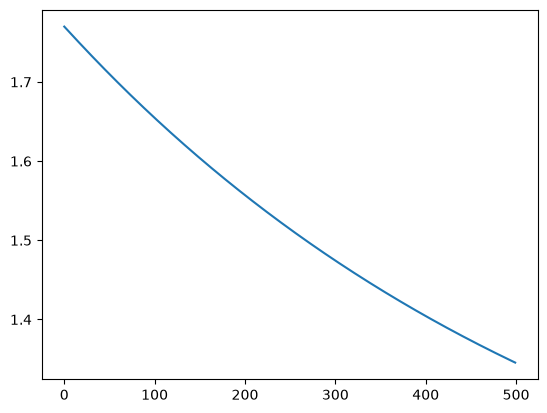

In [38]:
plt.plot(temperature_loss_history)

In [39]:
cali_proba = torch.softmax(cali_logits, dim=-1)

In [40]:
acc = accuracy(
    cali_proba,
    validate_targets,
)

nll = neg_log_likelihood(
    cali_proba,
    validate_targets,
)

brier = brier_score(
    cali_proba,
    validate_targets,
)

ece = expected_calibration_error(
    cali_proba,
    validate_targets,
)

acc, nll, brier, ece

(tensor(0.5833), tensor(1.3450), tensor(0.6389), tensor(0.3111))